In [38]:
import pandas as pd
import numpy as np

file_path = 'police_enforcement_2024_fines.xlsx'

df = pd.read_excel(file_path)

print(f"Original Size: {df.shape}")
df.head()

Original Size: (12179, 11)


,YEAR,START_DATE,END_DATE,JURISDICTION,LOCATION,AGE_GROUP,METRIC,DETECTION_METHOD,FINES,ARRESTS,CHARGES
0,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,non_wearing_seatbelts,Police issued,151,0,2
1,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,speed_fines,Police issued,1888,0,10
2,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,unlicensed_driving,Not applicable,109,0,431
3,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,65 and over,mobile_phone_use,Police issued,31,0,0
4,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,65 and over,non_wearing_seatbelts,Police issued,24,0,0


In [39]:
missing_info = df.isnull().sum()
print("Number of missing values:\n", missing_info)

Number of missing values:
 YEAR                0
START_DATE          0
END_DATE            0
JURISDICTION        0
LOCATION            0
AGE_GROUP           0
METRIC              0
DETECTION_METHOD    0
FINES               0
ARRESTS             0
CHARGES             0
dtype: int64


In [40]:
df_cleaned = df.drop_duplicates()

print(f"Size after removing duplicates: {df_cleaned.shape}")

Size after removing duplicates: (12179, 11)


In [41]:
df_mobile = df_cleaned[df_cleaned['METRIC'] == 'mobile_phone_use'].copy()

print(f"Mobile records: {len(df_mobile)}")

Mobile records: 2517


In [42]:
df_mobile['LOCATION'] = df_mobile['LOCATION'].replace({'All regions': 'Missing'})
df_mobile['AGE_GROUP'] = df_mobile['AGE_GROUP'].replace({'All ages': 'Missing'})
df_mobile['AGE_GROUP'] = df_mobile['AGE_GROUP'].replace({'Unknown': 'Missing'})
df_mobile['DETECTION_METHOD'] = df_mobile['DETECTION_METHOD'].replace({'Unknown': 'Others'})
df_mobile['LOCATION'] = df_mobile['LOCATION'].replace({'Unknown': 'Others'})

print("Current Age Group", df_mobile['AGE_GROUP'].unique())

Current Age Group ['65 and over' '17-25' '26-39' '40-64' 'Missing' '0-16']


In [43]:
df_final = df_mobile[(df_mobile['LOCATION'] != 'Missing') & (df_mobile['AGE_GROUP'] != 'Missing')]

print(f"Final Size: {df_final.shape}")
df_final.head()

Final Size: (2176, 11)


,YEAR,START_DATE,END_DATE,JURISDICTION,LOCATION,AGE_GROUP,METRIC,DETECTION_METHOD,FINES,ARRESTS,CHARGES
3,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,65 and over,mobile_phone_use,Police issued,31,0,0
10,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,17-25,mobile_phone_use,Police issued,6,0,0
14,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,26-39,mobile_phone_use,Police issued,11,0,0
18,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,40-64,mobile_phone_use,Police issued,3,0,0
22,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,65 and over,mobile_phone_use,Police issued,2,0,0


In [44]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2176 entries, 3 to 12178
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   YEAR              2176 non-null   int64         
 1   START_DATE        2176 non-null   datetime64[ns]
 2   END_DATE          2176 non-null   datetime64[ns]
 3   JURISDICTION      2176 non-null   object        
 4   LOCATION          2176 non-null   object        
 5   AGE_GROUP         2176 non-null   object        
 6   METRIC            2176 non-null   object        
 7   DETECTION_METHOD  2176 non-null   object        
 8   FINES             2176 non-null   int64         
 9   ARRESTS           2176 non-null   int64         
 10  CHARGES           2176 non-null   int64         
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 204.0+ KB


### Question 1: How have mobile phone enforcement fines changed across Australia from 2008 to 2024?


In [45]:
# Import thư viện trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách (style) cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

In [46]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

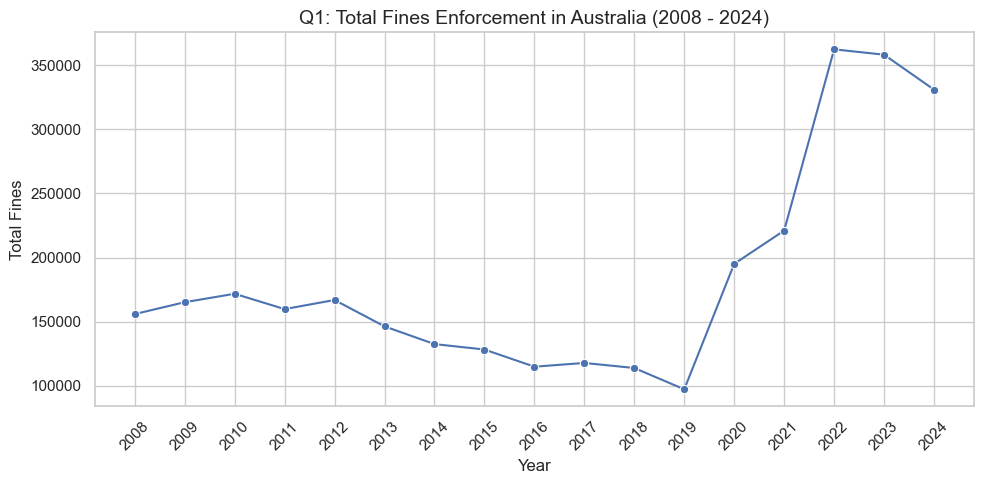

In [47]:
q1_trend = df_mobile.groupby('YEAR')['FINES'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=q1_trend, x='YEAR', y='FINES', marker='o', color='b')
plt.title('Q1: Total Fines Enforcement in Australia (2008 - 2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Fines')
plt.xticks(q1_trend['YEAR'], rotation=45)
plt.tight_layout()
plt.show()

### Question 2: Which jurisdictions consistently record the highest number of mobile phone infringement fines?

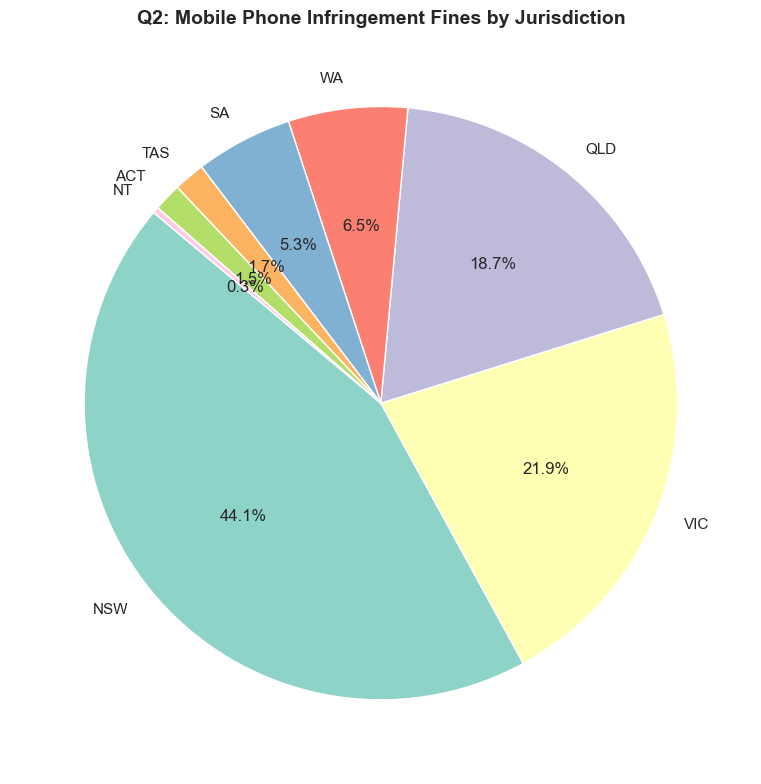

In [48]:
# Group by Jurisdiction and calculate total fines
q2_jurisdiction = df_mobile.groupby('JURISDICTION')['FINES'].sum().reset_index()

# Sort values so the pie chart looks organized
q2_jurisdiction = q2_jurisdiction.sort_values(by='FINES', ascending=False)

# Plotting the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(q2_jurisdiction['FINES'], 
        labels=q2_jurisdiction['JURISDICTION'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Set3'))

plt.title('Q2: Mobile Phone Infringement Fines by Jurisdiction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Question 3: How do enforcement actions vary across age groups?

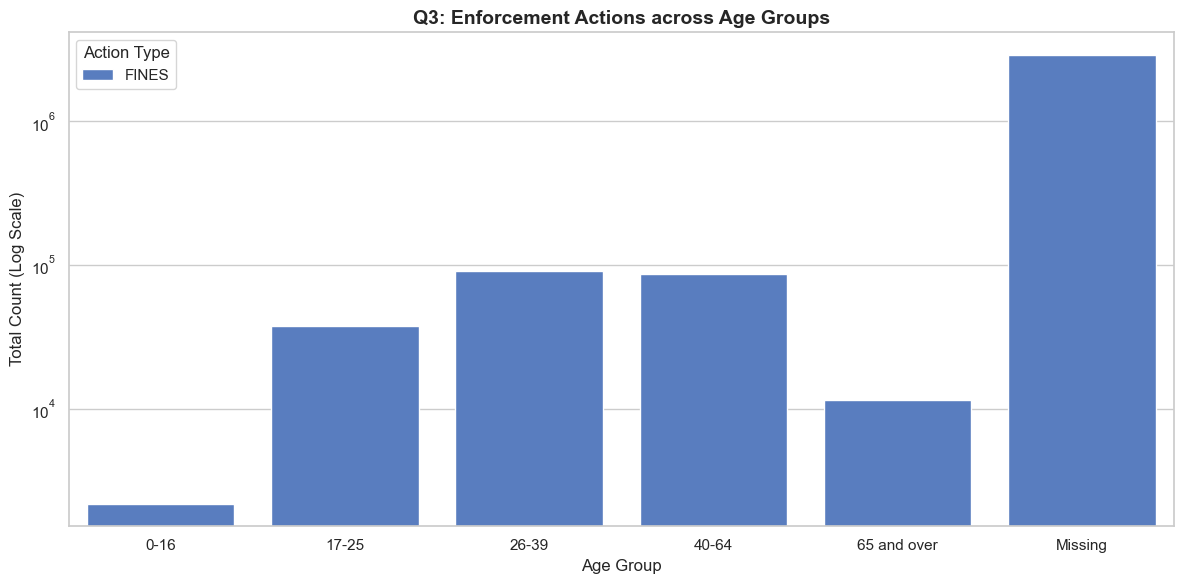

In [49]:
# Group by Age Group
q3_age = df_mobile.groupby('AGE_GROUP')[['FINES']].sum().reset_index()

# Melt the data (Unpivot) for seaborn plotting
q3_melted = q3_age.melt(id_vars='AGE_GROUP', var_name='Enforcement Action', value_name='Total Count')

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q3_melted, x='AGE_GROUP', y='Total Count', hue='Enforcement Action', palette='muted')

plt.title('Q3: Enforcement Actions across Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Using Log Scale because Fines are massively larger than Arrests/Charges
plt.yscale('log') 
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Question 4: What is the composition of enforcement actions?

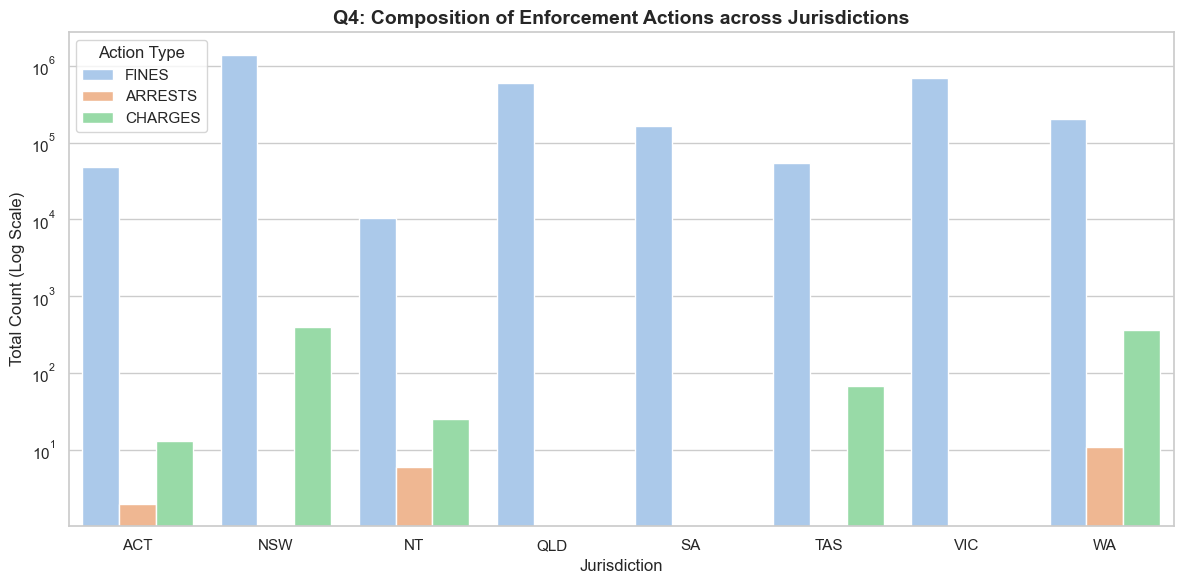

In [50]:
# Group by Jurisdiction and calculate total Fines, Arrests, and Charges
q4_jurisdiction = df_mobile.groupby('JURISDICTION')[['FINES', 'ARRESTS', 'CHARGES']].sum().reset_index()

# Melt the dataframe (Unpivot) to make it suitable for seaborn barplot
q4_melted = q4_jurisdiction.melt(id_vars='JURISDICTION', 
                                 var_name='Action Type', 
                                 value_name='Total Count')

# Plotting the Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q4_melted, x='JURISDICTION', y='Total Count', hue='Action Type', palette='pastel')

# Set English titles and labels
plt.title('Q4: Composition of Enforcement Actions across Jurisdictions', fontsize=14, fontweight='bold')
plt.xlabel('Jurisdiction', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Apply Log Scale because Fines are significantly higher than Arrests and Charges
plt.yscale('log')

# Customize the legend
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Question 5: How does enforcement vary by location type?

/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_39593/100805266.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')


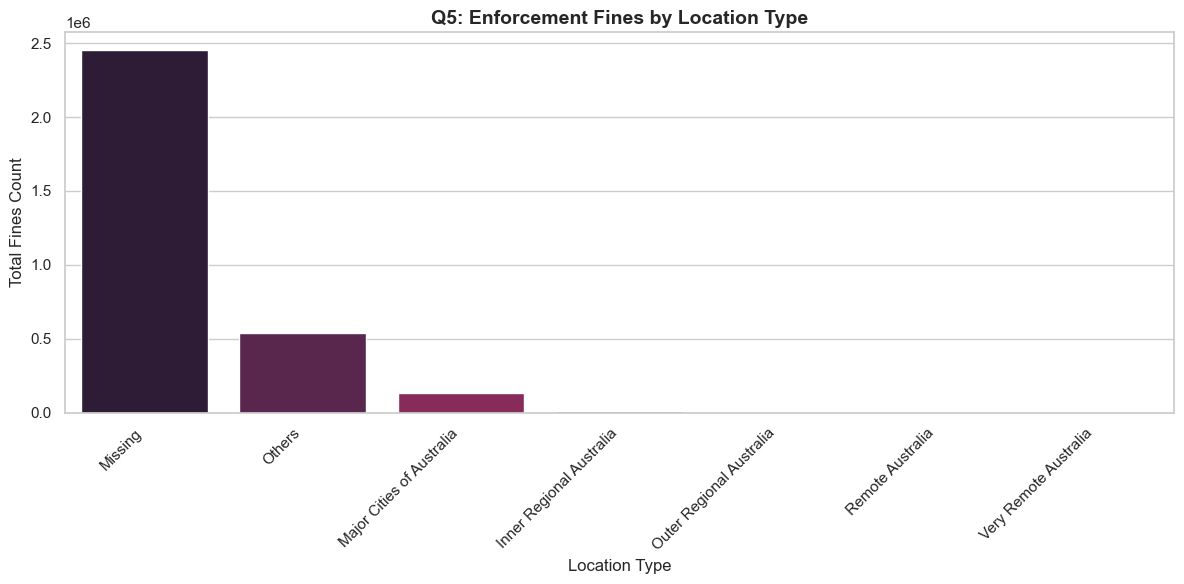

In [51]:
# Group by Location
q5_location = df_mobile.groupby('LOCATION')['FINES'].sum().reset_index()
q5_location = q5_location.sort_values(by='FINES', ascending=False)

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')

plt.title('Q5: Enforcement Fines by Location Type', fontsize=14, fontweight='bold')
plt.xlabel('Location Type', fontsize=12)
plt.ylabel('Total Fines Count', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate X labels so they don't overlap

plt.tight_layout()
plt.show()

### Q1 (Filtered): How have mobile phone enforcement fines changed across Australia from 2008 to 2024? 


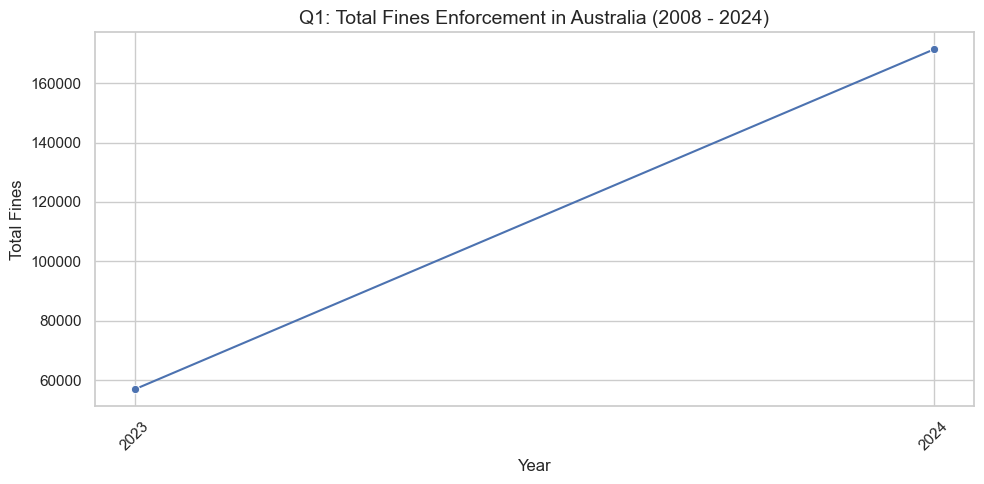

In [52]:
q1_trend = df_final.groupby('YEAR')['FINES'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=q1_trend, x='YEAR', y='FINES', marker='o', color='b')
plt.title('Q1: Total Fines Enforcement in Australia (2008 - 2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Fines')
plt.xticks(q1_trend['YEAR'], rotation=45)
plt.tight_layout()
plt.show()

### Q2 (Filtered): Which jurisdictions consistently record the highest number of mobile phone infringement fines?

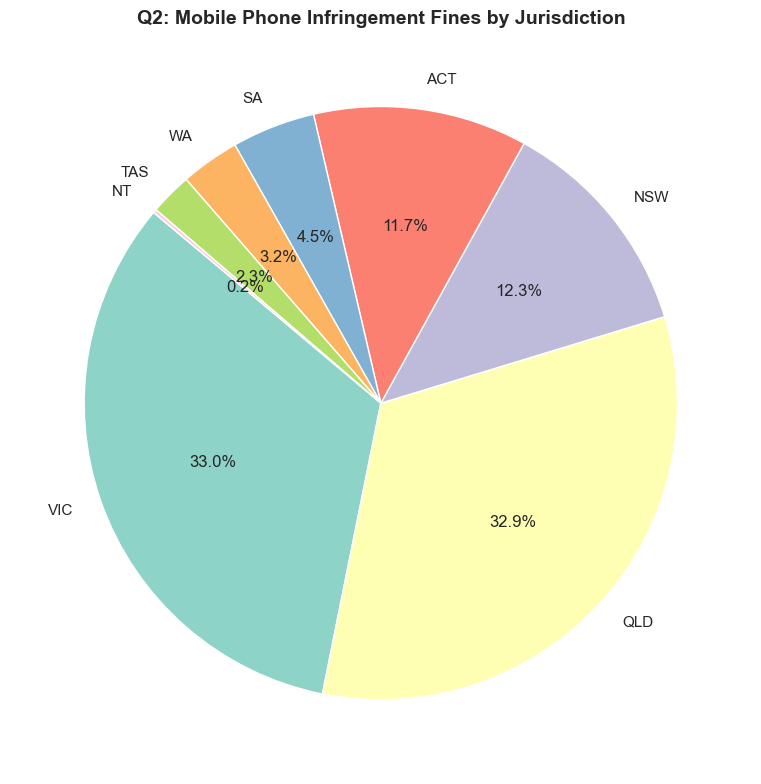

In [53]:
# Group by Jurisdiction and calculate total fines
q2_jurisdiction = df_final.groupby('JURISDICTION')['FINES'].sum().reset_index()

# Sort values so the pie chart looks organized
q2_jurisdiction = q2_jurisdiction.sort_values(by='FINES', ascending=False)

# Plotting the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(q2_jurisdiction['FINES'], 
        labels=q2_jurisdiction['JURISDICTION'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Set3'))

plt.title('Q2: Mobile Phone Infringement Fines by Jurisdiction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q3 (Filtered): How do enforcement actions vary across age groups?

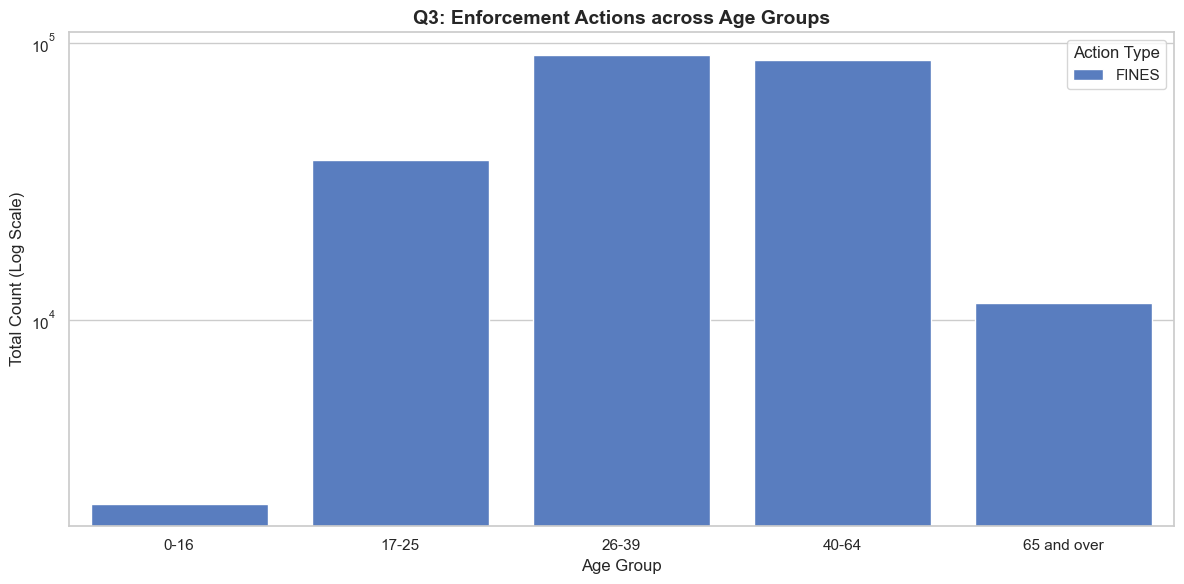

In [54]:
# Group by Age Group
q3_age = df_final.groupby('AGE_GROUP')[['FINES']].sum().reset_index()

# Melt the data (Unpivot) for seaborn plotting
q3_melted = q3_age.melt(id_vars='AGE_GROUP', var_name='Enforcement Action', value_name='Total Count')

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q3_melted, x='AGE_GROUP', y='Total Count', hue='Enforcement Action', palette='muted')

plt.title('Q3: Enforcement Actions across Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Using Log Scale because Fines are massively larger than Arrests/Charges
plt.yscale('log') 
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Q4 (Filtered): What is the composition of enforcement actions?

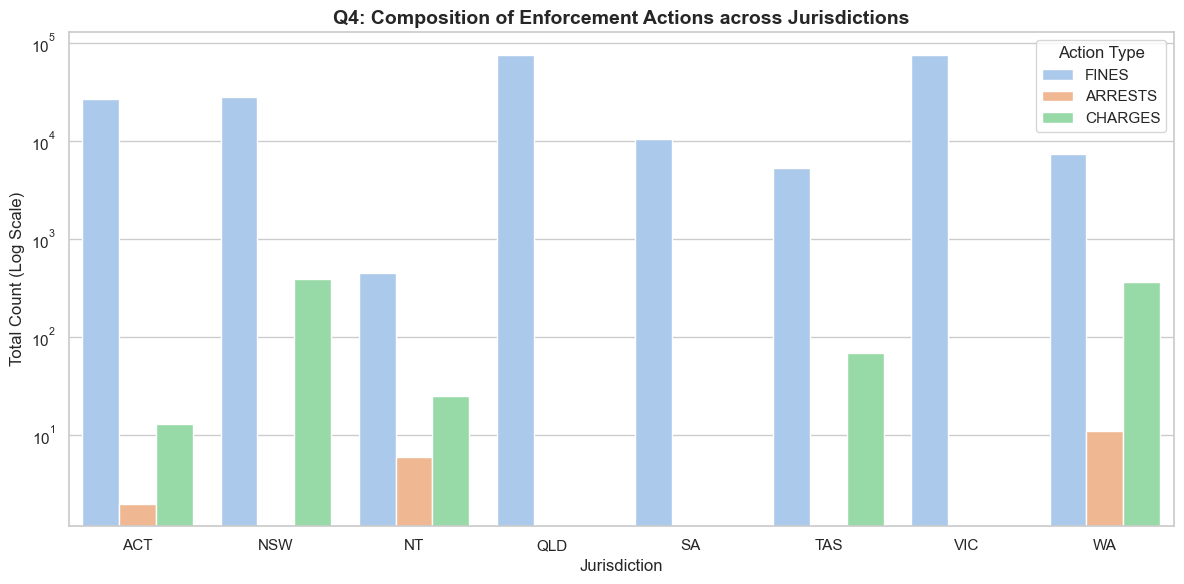

In [55]:
# Group by Jurisdiction and calculate total Fines, Arrests, and Charges
q4_jurisdiction = df_final.groupby('JURISDICTION')[['FINES', 'ARRESTS', 'CHARGES']].sum().reset_index()

# Melt the dataframe (Unpivot) to make it suitable for seaborn barplot
q4_melted = q4_jurisdiction.melt(id_vars='JURISDICTION', 
                                 var_name='Action Type', 
                                 value_name='Total Count')

# Plotting the Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q4_melted, x='JURISDICTION', y='Total Count', hue='Action Type', palette='pastel')

# Set English titles and labels
plt.title('Q4: Composition of Enforcement Actions across Jurisdictions', fontsize=14, fontweight='bold')
plt.xlabel('Jurisdiction', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Apply Log Scale because Fines are significantly higher than Arrests and Charges
plt.yscale('log')

# Customize the legend
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Q5 (Filtered): How does enforcement vary by location type?

/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_39593/3426752272.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')


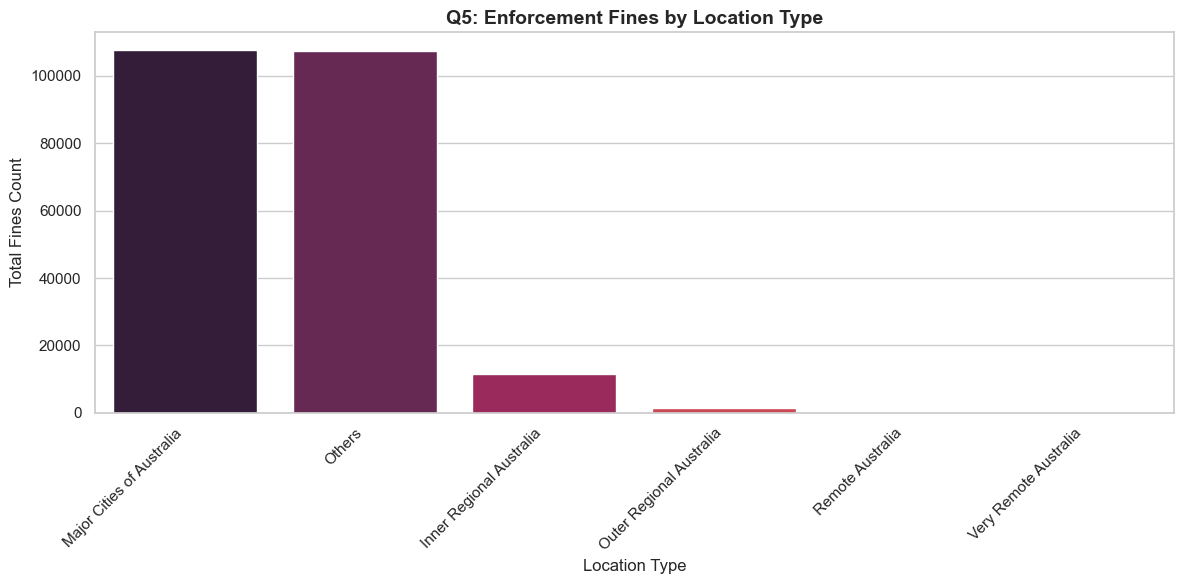

In [56]:
# Group by Location
q5_location = df_final.groupby('LOCATION')['FINES'].sum().reset_index()
q5_location = q5_location.sort_values(by='FINES', ascending=False)

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')

plt.title('Q5: Enforcement Fines by Location Type', fontsize=14, fontweight='bold')
plt.xlabel('Location Type', fontsize=12)
plt.ylabel('Total Fines Count', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate X labels so they don't overlap

plt.tight_layout()
plt.show()

### Load & Process Population Dataset

In [57]:


# Load dataset
pop_file = 'population_state_territory.xlsx'
sheet_name = 'Data1' 
# skiprows=9 to take only total population of each jurisdiction
df_pop_raw = pd.read_excel(pop_file,sheet_name,skiprows=10, header=None)

# Rename column name
target_columns = [0, 18, 19, 20, 21, 22, 23, 24, 25] 
df_pop = df_pop_raw.iloc[:, target_columns].copy()
df_pop.columns = ['DATE', 'NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']

# Convert DATE into datetime và extract YEAR
df_pop['DATE'] = pd.to_datetime(df_pop['DATE'])
df_pop['YEAR'] = df_pop['DATE'].dt.year

# Calculate average number of population by year
df_pop_yearly = df_pop.groupby('YEAR')[['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']].mean().reset_index()

# Convert into int
for col in ['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']:
    df_pop_yearly[col] = df_pop_yearly[col].round().astype(int)

# Unpivot column
df_pop_clean = df_pop_yearly.melt(id_vars='YEAR', 
                                  var_name='JURISDICTION', 
                                  value_name='POPULATION')

print(df_pop_clean)


     YEAR JURISDICTION  POPULATION
0    1981          NSW     7507109
1    1982          NSW     7615477
2    1983          NSW     7718404
3    1984          NSW     7813715
4    1985          NSW     7919245
..    ...          ...         ...
347  2020          ACT      247493
348  2021          ACT      248212
349  2022          ACT      250452
350  2023          ACT      253264
351  2024          ACT      255004

[352 rows x 3 columns]


In [58]:
# Merge 2 dataset using inner join 
df_merged = pd.merge(df_final, df_pop_clean, on=['YEAR', 'JURISDICTION'], how='inner')

# Normalization (Calculate fines rate over 100k)
df_merged['FINES_PER_100K'] = (df_merged['FINES'] / df_merged['POPULATION']) * 100000

print(f"Final size after Merge: {df_merged.shape}")
df_merged[['YEAR', 'JURISDICTION', 'FINES', 'POPULATION', 'FINES_PER_100K']].head()

Final size after Merge: (2176, 13)


,YEAR,JURISDICTION,FINES,POPULATION,FINES_PER_100K
0,2024,NSW,31,13698705,0.226299
1,2024,NSW,6,13698705,0.043800
2,2024,NSW,11,13698705,0.080300
3,2024,NSW,3,13698705,0.021900
4,2024,NSW,2,13698705,0.014600
